### House Price prediction using linear regression

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [32]:
#load dataset

housing = fetch_california_housing()

#housing
df = pd.DataFrame(housing.data,columns = housing.feature_names)

#target column
df['Price'] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  ...  AveOccup  Latitude  Longitude  Price
0  8.3252      41.0  6.984127   1.023810  ...  2.555556     37.88    -122.23  4.526
1  8.3014      21.0  6.238137   0.971880  ...  2.109842     37.86    -122.22  3.585
2  7.2574      52.0  8.288136   1.073446  ...  2.802260     37.85    -122.24  3.521
3  5.6431      52.0  5.817352   1.073059  ...  2.547945     37.85    -122.25  3.413
4  3.8462      52.0  6.281853   1.081081  ...  2.181467     37.85    -122.25  3.422

[5 rows x 9 columns]


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [34]:
df.isnull().sum()  #checking for missing values

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [38]:
# Select features and target 

x = df[['MedInc']]

y = df["Price"]

In [39]:
print(x.head(),y.head())

   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


In [40]:
#split the Dataset

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=42) 

In [41]:
print(x.shape,x_train.shape,x_test.shape)

(20640, 1) (16512, 1) (4128, 1)


In [42]:
#create model
model = LinearRegression()

In [43]:
#train model 
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
#predict values

y_pred = model.predict(x_test)

In [45]:
print(y_pred[:5])

[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318]


In [46]:
#compare Actual vs predicted

comparison = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

comparison.head(10)

,Actual,Predicted
20046,0.47700,1.149589
3024,0.45800,1.506069
15663,5.00001,1.903937
20484,2.18600,2.850594
9814,2.78000,2.006633
13311,1.58700,2.421652
7113,1.98200,2.576472
7668,1.57500,1.992292
18246,3.40000,2.458932
5723,4.46600,3.846774


In [47]:
#evaluate model 

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(mae,mse,rmse,r2)

0.629908653009376 0.7091157771765549 0.8420901241414455 0.45885918903846656


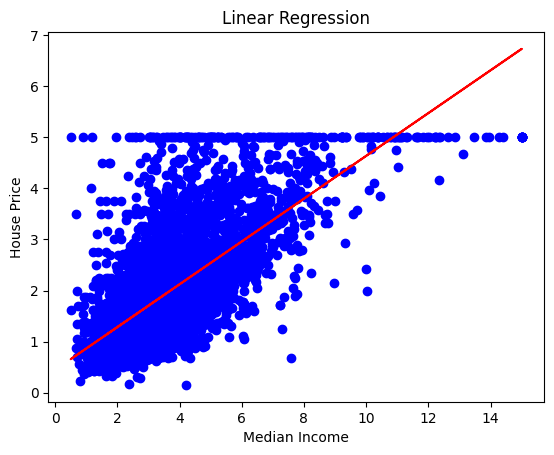

In [ ]:
#visaulization

plt.scatter(x_test,y_test,color = 'blue')
plt.plot(x_test,y_pred,color = 'red')

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Linear Regression")

plt.show()